# Notebook 03 - Data Training

In this notebook we perform the training our data using the method of Logistic Regression. 

## Setup

In [1]:
# General
import numpy as np                     
import pandas as pd      
import re              

# Plotting Options
from matplotlib import pyplot as plt                           
import seaborn as sns                                          
plt.rcParams['text.usetex'] = True                             
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  

# File management
from pathlib import Path                  
import os                     

# Machine learning tools 

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
from scipy.stats import loguniform
import tempfile

# Defines a function to find the project root directory by looking for a specific marker (default is 'data')
def find_project_root(start=Path.cwd(), marker='data'): 
    current = start
    while current != current.parent:
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root() 
os.chdir(PROJECT_ROOT) # go to the root of the project 

In [2]:
df_reviews = pd.read_csv('data/dataframes/gold/reviews.csv')

In [3]:
df_reviews.head()

,unique_id,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime,normalized_review_time,normalized_review,sentiment
0,5957,B002HJV4DE,"[1, 1]",1,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400,2013-10-08,great short read i didnt want to put it down s...,positive
1,1776,B001A06VJ8,"[0, 1]",1,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000,2012-12-31,i did not expect this type of book to be in li...,positive
2,3744,B0021L9YDK,"[6, 6]",1,Aislinn is a little girl with big dreams. Afte...,"12 7, 2009",A3J5NN6MJK4M4A,"Aubrie A. Dionne ""Fantasy, Sci Fi Author""",A story of a little girl with big dreams.,1260144000,2009-12-07,aislinn is a little girl with big dreams after...,positive
3,13641,B0038NN38W,"[1, 1]",0,This has the makings of a good story... unfort...,"08 18, 2011",A531QY5K7JVXI,Chicano,This story has potential but ultimately disapp...,1313625600,2011-08-18,this has the makings of a good story unfortuna...,negative
4,4448,B002AJ7X2C,"[1, 1]",1,I got this because I like collaborated short s...,"03 8, 2010",AN8ELR6AHMMQ,"Jessss ""I read to find stories that inspire m...",Good thriller,1268006400,2010-03-08,i got this because i like collaborated short s...,positive


## 1. Splitting data into test and train

In [4]:
# defining inputs and outputs

X = df_reviews['normalized_review']
y = df_reviews['rating']

In [5]:
# splitting into test and train 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

## 2. Defining the pipeline

In our pipeline we will add three processes to be made. 

    1. Vectorization: we need to convert the characters on the reviews into numbers in order to perform our analysis. The stop words, that is, words that need not to be converted will articles, connectors and so on. 
    
    2. Scaler: after the vectorization we standardize all of our vectors. StandardScaler adjust the scale of every number so they have an equal variance.

    3. Logistic Regression: this step applies the method of Logistic Regression to train our model. 

The stops words can be obtained with the command text.ENGLISH_STOP_WORDS. But this is not good for a sentiment analysis since those include words like "not", "no" and so on and this could be bad for negative reviews. Instead, we will define the stop words as 

In [6]:
stopwords = set(text.ENGLISH_STOP_WORDS) - {
    'not', 'no', 'nor', 'never', "n't"
}

Now we define our pipeline

In [7]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=list(stopwords))),
    ('scaler', StandardScaler(with_mean = False)),
    ('logreg', LogisticRegression(solver='saga', max_iter=5000, random_state=42))
])

The thing is that LogisticRegression has several hyperparamaters ([consult here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)). Thus, we need to choose which will be the best to obtain an accurate model. We can test this using GridSearchCV, which enables us to test the combinations of hyperparameters to obtain the one with the most accuracy, 

We define a dictionary to store the parameters we want to test. Since TfidfVectorizer also takes parameters, we add combinations for those as well

In [8]:
grid_parameters = {
    'tfidf__max_features': [500, 1000, 2000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'logreg__C': [0.1, 1, 10],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__max_iter': [5000, 6000]
}

In [9]:
# Setting up GridSearchCV
grid_search = GridSearchCV(
    pipeline,              # Pipeline with preprocessing steps and model
    grid_parameters,       # Dictionary with the combinations of hyperparameters to be tested
    cv = 3,                # Number of splits for cross-validation (3-fold cross-validation)
    n_jobs = -1,           # Uses all available CPU cores to speed up the process
    scoring = 'accuracy',  # Metric used to evaluate the performance of each combination (here, accuracy)
    verbose = 1            # Level of detail in the output during execution (1 shows basic progress)
)

## 3. Training the model

Now we provide the pipeline with the training data. The GridSearchCV executes the process .fit() and learn how to connect the rating to its review.  

In [11]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


,estimator,Pipeline(step...ver='saga'))])
,param_grid,"{'logreg__C': [0.1, 1, ...], 'logreg__max_iter': [5000, 6000], 'logreg__penalty': ['l1', 'l2'], 'tfidf__max_features': [500, 1000, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


The best parameters found were 

In [12]:
print("\nBest parameters found:\n")
print(grid_search.best_params_)


Best parameters found:

{'logreg__C': 0.1, 'logreg__max_iter': 5000, 'logreg__penalty': 'l1', 'tfidf__max_features': 2000, 'tfidf__ngram_range': (1, 2)}


Then we define the best model

In [22]:
best_model = grid_search.best_estimator_

## 4. Model evaluation

We now perform our test using this model to see how accurate it is

In [23]:
y_pred = best_model.predict(X_test)

In [24]:
# Calculating metric 

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names = ['Negative','Positive'])

In [25]:
print(f"\nModel Accuracy: {accuracy:.2%}\n")
print("Report of Classification:\n")
print(report)


Model Accuracy: 86.00%

Report of Classification:

              precision    recall  f1-score   support

    Negative       0.83      0.82      0.82      1200
    Positive       0.88      0.89      0.88      1800

    accuracy                           0.86      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.86      0.86      0.86      3000



## 4.1 Classification Metrics Explanation

### Accuracy

Out of all the reviews (positive and negative) that the model analyzed, what is the total percentage of correct predictions?

In our context: If you pass 100 reviews through the model it correctly classify 86 of them (regardless of whether they are positive or negative). This means an accuracy of 86%.



### Precision

This metric is calculated for each class.

#### Precision for the 'Positive' class
Of the reviews that the model labeled as "Positive," how many were actually positive?

In our context: Of 100 positive reviews, our model got 88 of them right. That means that 12 of them were false positives.


#### Precision for the 'Negative' class
Of the reviews that the model labeled as "Negative," how many were actually negative?

In our context: Of 100 negative reviews, our model got 83 of them right. That means that 17 of them were false negatives.


### Recall

This metric is also calculated for each class.

#### Recall for the 'Positive' class
Of all the reviews that were actually positive, how many did the model successfully identify?

In our context: We have 6000 positive values, since recall for this class was equal 89%, it got 5340 of them.  

**Importance:** Ensures you are capturing most of the positive feedback.


#### Recall for the 'Negative' class
Of all the reviews that were actually negative, how many did the model successfully identify?

In our context: We have 4000 negative values, since recall for this class was equal 82%, it got 3280 of them. 


### F1-Score

A balanced metric between precision and recall for each class.

In our context: The F1-score will only be high if both precision and recall are high. It avoids cases where one is high and the other is low, providing a balanced evaluation.

### Support

How many samples of each class exist in the test dataset?

In our context: There were 1800 positive samples and 1200 negative samples.


We can also plot a confusion matrix to visualize the result described above.

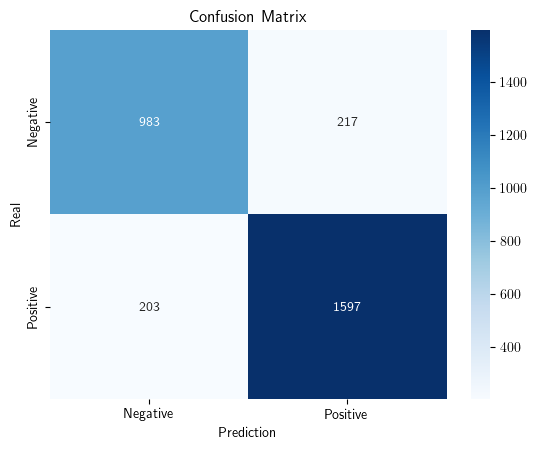

In [26]:
# Visualizing a Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Negative','Positive'],
            yticklabels = ['Negative','Positive'])
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.show()

Since this model has a good accuracy (it could be better testing other parameters but that would require more time and processing power) we can save the model

In [27]:
joblib.dump(best_model, 'data/model/best_model.joblib')

['data/model/best_model.joblib']

And delete it from the memory 

In [28]:
del best_model